
# 06a - Calibración mediante *split conformal* del modelo base ingenuo estacional

Este notebook construye intervalos de predicción para el modelo base ingenuo estacional mediante una estrategia de *split conformal* basada en residuos absolutos.

El modelo base no se entrena en un sentido paramétrico: se define mediante una regla de persistencia diaria. Ahora bien, como veremos a continuación, los intervalos sí se calibran utilizando el conjunto de calibración de 2023.



## Objetivos del notebook

1. Cargar las predicciones puntuales del modelo base ingenuo estacional
2. Utilizar el conjunto de calibración para calcular los residuos absolutos
3. Obtener el cuantil necesario para obtener una cobertura nominal del 80 %
4. Construir los intervalos de predicción
5. Evaluar la cobertura empírica, la anchura media y el *interval score*
6. Guardar los intervalos, las métricas y las figuras de diagnóstico
7. Mantener el conjunto de prueba reservado para la evaluación final


In [14]:

from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display



## Configuración general

Se fija una cobertura nominal del 80 %, equivalente a $\alpha = 0.2$. Esta elección permite construir intervalos suficientemente informativos sin que su anchura pueda resultar excesiva.


In [ ]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "reports").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

REPORTS_PREDICTIONS_DIR = PROJECT_ROOT / "reports" / "predictions"
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for path in [REPORTS_INTERVALS_DIR, REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_ID = "baseline_seasonal_naive"
MODEL_DISPLAY = "Modelo base ingenuo estacional"
PREDICTION_PREFIX = "baseline_seasonal_naive"
INTERVAL_PREFIX = "split_conformal_baseline"

HORIZONS: List[int] = [1, 4, 12, 24]
CALIBRATION_SPLIT = "calibration"
VALIDATION_SPLIT = "validation"
TEST_SPLIT = "test"

ALPHA = 0.20
NOMINAL_COVERAGE = 1 - ALPHA

EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 14 * 24

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Predicciones: {REPORTS_PREDICTIONS_DIR}")
print(f"Intervalos: {REPORTS_INTERVALS_DIR}")
print(f"Tablas: {REPORTS_TABLES_DIR}")
print(f"Figuras: {REPORTS_FIGURES_DIR}")
print(f"Cobertura nominal: {NOMINAL_COVERAGE:.0%} (alpha={ALPHA})")


Raíz del proyecto: c:\trabajo_github
Predicciones: c:\trabajo_github\reports\predictions
Intervalos: c:\trabajo_github\reports\intervals
Tablas: c:\trabajo_github\reports\tables
Figuras: c:\trabajo_github\reports\figures
Cobertura nominal: 80% (alpha=0.2)



## Carga de las predicciones del modelo base

Se cargan las predicciones puntuales generadas en el notebook `03_baseline_seasonal_naive`. En esta fase se utilizarán únicamente los bloques de calibración y validación.


In [16]:

REQUIRED_COLUMNS = {
    "horizon",
    "split",
    "origin_timestamp",
    "target_timestamp",
    "y_true",
    "y_pred",
}

def load_baseline_predictions(horizon: int) -> pd.DataFrame:
    """Carga las predicciones del modelo base para un horizonte concreto."""
    file_path = REPORTS_PREDICTIONS_DIR / f"{PREDICTION_PREFIX}_h{horizon:02d}.parquet"

    if not file_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {file_path}. Debe ejecutarse primero el notebook "
            "03_baseline_seasonal_naive.ipynb."
        )

    pred = pd.read_parquet(file_path).copy()
    missing_columns = REQUIRED_COLUMNS.difference(pred.columns)

    if missing_columns:
        raise ValueError(
            f"El archivo {file_path} no contiene las columnas esperadas: "
            f"{sorted(missing_columns)}"
        )

    pred["horizon"] = int(horizon)
    pred["model"] = MODEL_ID
    pred["model_display"] = MODEL_DISPLAY
    pred["origin_timestamp"] = pd.to_datetime(pred["origin_timestamp"])
    pred["target_timestamp"] = pd.to_datetime(pred["target_timestamp"])
    pred["is_evaluable"] = pred["y_true"].notna() & pred["y_pred"].notna()

    return pred

prediction_frames = [load_baseline_predictions(h) for h in HORIZONS]
baseline_predictions = pd.concat(prediction_frames, ignore_index=True)
baseline_predictions = baseline_predictions.sort_values(
    ["horizon", "split", "target_timestamp"]
).reset_index(drop=True)

print(f"Filas cargadas: {len(baseline_predictions):,}")
display(baseline_predictions.head())


Filas cargadas: 68,176


,horizon,split,origin_timestamp,target_timestamp,y_true,y_pred,model,baseline_rule,baseline_source_timestamp,source_lag_from_origin_h,is_evaluable,residual,abs_error,squared_error,model_display
0,1,calibration,2022-12-31 23:00:00,2023-01-01 00:00:00,1.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 00:00:00,23.000,True,-16.000,16.000,256.000,Modelo base ingenuo estacional
1,1,calibration,2023-01-01 00:00:00,2023-01-01 01:00:00,1.000,25.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 01:00:00,23.000,True,-24.000,24.000,576.000,Modelo base ingenuo estacional
2,1,calibration,2023-01-01 01:00:00,2023-01-01 02:00:00,1.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 02:00:00,23.000,True,-16.000,16.000,256.000,Modelo base ingenuo estacional
3,1,calibration,2023-01-01 02:00:00,2023-01-01 03:00:00,1.000,32.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 03:00:00,23.000,True,-31.000,31.000,961.000,Modelo base ingenuo estacional
4,1,calibration,2023-01-01 03:00:00,2023-01-01 04:00:00,1.000,46.000,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 04:00:00,23.000,True,-45.000,45.000,"2,025.000",Modelo base ingenuo estacional



## Control previo de disponibilidad

Antes de calibrar los intervalos, se verifica cuántas observaciones son evaluables por bloque. Una observación será evaluable si dispone, simultáneamente, del valor observado (`y_true`) y de la predicción puntual (`y_pred`).


In [17]:


def summarize_availability(predictions: pd.DataFrame) -> pd.DataFrame:
    """Resume disponibilidad y rango temporal por horizonte y split."""
    rows = []

    for (horizon, split), group in predictions.groupby(["horizon", "split"], sort=True):
        rows.append(
            {
                "model": MODEL_ID,
                "model_display": MODEL_DISPLAY,
                "horizon": int(horizon),
                "split": split,
                "n_rows": int(len(group)),
                "n_evaluable": int(group["is_evaluable"].sum()),
                "target_start": group["target_timestamp"].min(),
                "target_end": group["target_timestamp"].max(),
                "missing_y_pct": float(group["y_true"].isna().mean() * 100),
                "missing_pred_pct": float(group["y_pred"].isna().mean() * 100),
            }
        )

    return pd.DataFrame(rows).sort_values(["split", "horizon"]).reset_index(drop=True)

availability_df = summarize_availability(baseline_predictions)
display(availability_df)


,model,model_display,horizon,split,n_rows,n_evaluable,target_start,target_end,missing_y_pct,missing_pred_pct
0,baseline_seasonal_naive,Modelo base ingenuo estacional,1,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.000,1.545
1,baseline_seasonal_naive,Modelo base ingenuo estacional,4,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.000,1.545
2,baseline_seasonal_naive,Modelo base ingenuo estacional,12,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.000,1.545
3,baseline_seasonal_naive,Modelo base ingenuo estacional,24,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.000,1.545
4,baseline_seasonal_naive,Modelo base ingenuo estacional,1,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.000,2.039
5,baseline_seasonal_naive,Modelo base ingenuo estacional,4,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.000,2.039
6,baseline_seasonal_naive,Modelo base ingenuo estacional,12,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.000,2.039
7,baseline_seasonal_naive,Modelo base ingenuo estacional,24,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.000,2.039



## Calibración mediante *split conformal*

Para el modelo base, como se explica en la memoria, se emplea una versión clásica de *split conformal* basada en residuos absolutos. En el conjunto de calibración se calculan las puntuaciones de no conformidad, es decir:

$$
s_i = |y_i - \hat{y}_i|.
$$

A partir de estas puntuaciones, se obtiene el cuantil conforme \(\hat{q}\), que se suma y se resta a la predicción puntual para construir el intervalo:

$$
\hat{C}(x) = [\hat{y}(x) - \hat{q},\; \hat{y}(x) + \hat{q}].
$$

Se utiliza la corrección finita habitual de *split conformal*, tomando el orden:

$$
k = \lceil (n_{cal} + 1)(1 - \alpha) \rceil.
$$

Como se toma $\alpha = 0.2$, la cobertura nominal es del 80 %.


In [18]:


def conformal_quantile(scores: np.ndarray, alpha: float) -> tuple[float, int, int]:
    """Calcula el cuantil conforme con corrección finita.

    Parameters
    ----------
    scores: Puntuaciones de no conformidad. En este caso, residuos absolutos.
    alpha: Nivel de significación. Para cobertura nominal del 80 %, alpha = 0.2.

    Returns
    -------
    q_hat: Cuantil conforme.
    k: Orden usado sobre los residuos ordenados, con base 1.
    n: Número de residuos de calibración.
    """
    clean_scores = np.asarray(scores, dtype=float)
    clean_scores = clean_scores[~np.isnan(clean_scores)]

    if len(clean_scores) == 0:
        raise ValueError("No hay residuos disponibles para calibrar.")

    sorted_scores = np.sort(clean_scores)
    n = len(sorted_scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))

    if k > n:
        # Este caso puede aparecer con muestras pequeñas o alpha muy bajo.
        # Con n grande no debería ocurrir; se deja controlado por seguridad.
        q_hat = np.inf
    else:
        q_hat = float(sorted_scores[k - 1])

    return q_hat, k, n


calibration_rows = []
calibration_residual_frames = []
q_hat_by_horizon: Dict[int, float] = {}

for horizon in HORIZONS:
    calibration = baseline_predictions.loc[
        (baseline_predictions["horizon"] == horizon)
        & (baseline_predictions["split"] == CALIBRATION_SPLIT)
        & (baseline_predictions["is_evaluable"])
    ].copy()

    calibration["residual"] = calibration["y_true"] - calibration["y_pred"]
    calibration["abs_residual"] = calibration["residual"].abs()

    q_hat, k_order, n_calibration = conformal_quantile(
        calibration["abs_residual"].to_numpy(),
        alpha=ALPHA,
    )
    q_hat_by_horizon[horizon] = q_hat

    calibration_rows.append(
        {
            "model": MODEL_ID,
            "model_display": MODEL_DISPLAY,
            "method": "split_conformal",
            "horizon": horizon,
            "alpha": ALPHA,
            "nominal_coverage": NOMINAL_COVERAGE,
            "n_calibration": n_calibration,
            "k_order": k_order,
            "q_hat": q_hat,
            "mean_abs_residual_calibration": float(calibration["abs_residual"].mean()),
            "median_abs_residual_calibration": float(calibration["abs_residual"].median()),
            "max_abs_residual_calibration": float(calibration["abs_residual"].max()),
        }
    )

    calibration_residual_frames.append(
        calibration[[
            "model",
            "model_display",
            "horizon",
            "split",
            "origin_timestamp",
            "target_timestamp",
            "y_true",
            "y_pred",
            "residual",
            "abs_residual",
        ]]
    )

calibration_summary_df = pd.DataFrame(calibration_rows)
calibration_residuals_df = pd.concat(calibration_residual_frames, ignore_index=True)

display(calibration_summary_df)


,model,model_display,method,horizon,alpha,nominal_coverage,n_calibration,k_order,q_hat,mean_abs_residual_calibration,median_abs_residual_calibration,max_abs_residual_calibration
0,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,1,0.200,0.800,8474,6780,27.000,16.183,13.000,85.000
1,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,4,0.200,0.800,8474,6780,27.000,16.183,13.000,85.000
2,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,12,0.200,0.800,8474,6780,27.000,16.183,13.000,85.000
3,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,24,0.200,0.800,8474,6780,27.000,16.183,13.000,85.000



## Construcción de los intervalos en el conjunto de validación

Una vez obtenido $\hat{q}$ en el conjunto de calibración, se construyen intervalos sobre el conjunto de validación. El conjunto de prueba permanece, pues, sin utilizar.


In [19]:

interval_frames = []

for horizon in HORIZONS:
    validation = baseline_predictions.loc[
        (baseline_predictions["horizon"] == horizon)
        & (baseline_predictions["split"] == VALIDATION_SPLIT)
        & (baseline_predictions["is_evaluable"])
    ].copy()

    q_hat = q_hat_by_horizon[horizon]

    validation["method"] = "split_conformal"
    validation["alpha"] = ALPHA
    validation["nominal_coverage"] = NOMINAL_COVERAGE
    validation["q_hat"] = q_hat
    validation["lower"] = validation["y_pred"] - q_hat
    validation["upper"] = validation["y_pred"] + q_hat
    validation["interval_width"] = validation["upper"] - validation["lower"]
    validation["covered"] = (
        (validation["y_true"] >= validation["lower"])
        & (validation["y_true"] <= validation["upper"])
    )
    validation["miss_lower"] = validation["y_true"] < validation["lower"]
    validation["miss_upper"] = validation["y_true"] > validation["upper"]

    interval_frames.append(validation)

baseline_intervals = pd.concat(interval_frames, ignore_index=True)
baseline_intervals = baseline_intervals.sort_values(
    ["horizon", "target_timestamp"]
).reset_index(drop=True)

display(baseline_intervals.head())
print(f"Intervalos de validación generados: {len(baseline_intervals):,}")


,horizon,split,origin_timestamp,target_timestamp,y_true,y_pred,model,baseline_rule,baseline_source_timestamp,source_lag_from_origin_h,is_evaluable,residual,abs_error,squared_error,model_display,method,alpha,nominal_coverage,q_hat,lower,upper,interval_width,covered,miss_lower,miss_upper
0,1,validation,2023-12-31 23:00:00,2024-01-01 00:00:00,5.000,5.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 00:00:00,23.000,True,0.000,0.000,0.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-22.000,32.000,54.000,True,False,False
1,1,validation,2024-01-01 00:00:00,2024-01-01 01:00:00,10.000,9.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 01:00:00,23.000,True,1.000,1.000,1.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-18.000,36.000,54.000,True,False,False
2,1,validation,2024-01-01 01:00:00,2024-01-01 02:00:00,6.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 02:00:00,23.000,True,-11.000,11.000,121.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-10.000,44.000,54.000,True,False,False
3,1,validation,2024-01-01 02:00:00,2024-01-01 03:00:00,2.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 03:00:00,23.000,True,-15.000,15.000,225.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-10.000,44.000,54.000,True,False,False
4,1,validation,2024-01-01 03:00:00,2024-01-01 04:00:00,2.000,15.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 04:00:00,23.000,True,-13.000,13.000,169.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-12.000,42.000,54.000,True,False,False


Intervalos de validación generados: 33,060



## Evaluación de los intervalos

Se evalúan tres métricas principales:

- **Cobertura empírica**: la proporción de valores observados contenidos en el intervalo
- **Anchura media**: el tamaño promedio del intervalo
- **Interval score**: métrica que valora la estrechez y penaliza los valores observados fuera del intervalo.

Para un intervalo $[l_i, u_i]$, el *interval score* para nivel \(\alpha\) se define como:

$$
S_{\alpha}(l_i, u_i; y_i) = (u_i - l_i)
+ \frac{2}{\alpha}(l_i - y_i)\mathbb{1}\{y_i < l_i\}
+ \frac{2}{\alpha}(y_i - u_i)\mathbb{1}\{y_i > u_i\}.
$$


In [20]:


def interval_score(y_true: pd.Series, lower: pd.Series, upper: pd.Series, alpha: float) -> np.ndarray:
    """Calcula el interval score para intervalos centrales."""
    y = np.asarray(y_true, dtype=float)
    l = np.asarray(lower, dtype=float)
    u = np.asarray(upper, dtype=float)

    width = u - l
    lower_penalty = (2 / alpha) * (l - y) * (y < l)
    upper_penalty = (2 / alpha) * (y - u) * (y > u)

    return width + lower_penalty + upper_penalty

baseline_intervals["interval_score"] = interval_score(
    y_true=baseline_intervals["y_true"],
    lower=baseline_intervals["lower"],
    upper=baseline_intervals["upper"],
    alpha=ALPHA,
)

metric_rows = []

for horizon, group in baseline_intervals.groupby("horizon", sort=True):
    metric_rows.append(
        {
            "model": MODEL_ID,
            "model_display": MODEL_DISPLAY,
            "method": "split_conformal",
            "horizon": int(horizon),
            "alpha": ALPHA,
            "nominal_coverage": NOMINAL_COVERAGE,
            "n_validation": int(len(group)),
            "empirical_coverage": float(group["covered"].mean()),
            "coverage_error": float(group["covered"].mean() - NOMINAL_COVERAGE),
            "mean_width": float(group["interval_width"].mean()),
            "median_width": float(group["interval_width"].median()),
            "mean_interval_score": float(group["interval_score"].mean()),
            "median_interval_score": float(group["interval_score"].median()),
            "miss_lower_pct": float(group["miss_lower"].mean() * 100),
            "miss_upper_pct": float(group["miss_upper"].mean() * 100),
            "mean_q_hat": float(group["q_hat"].mean()),
        }
    )

interval_metrics_df = pd.DataFrame(metric_rows)
display(interval_metrics_df)


,model,model_display,method,horizon,alpha,nominal_coverage,n_validation,empirical_coverage,coverage_error,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_pct,miss_upper_pct,mean_q_hat
0,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,1,0.200,0.800,8265,0.800,-0.000,54.000,54.000,79.195,54.000,10.236,9.800,27.000
1,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,4,0.200,0.800,8265,0.800,-0.000,54.000,54.000,79.195,54.000,10.236,9.800,27.000
2,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,12,0.200,0.800,8265,0.800,-0.000,54.000,54.000,79.195,54.000,10.236,9.800,27.000
3,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,24,0.200,0.800,8265,0.800,-0.000,54.000,54.000,79.195,54.000,10.236,9.800,27.000



## Guardado de los resultados

Se guardan los residuos de calibración, los intervalos de validación y las métricas asociadas. Estos archivos serán utilizados más adelante para la comparación común entre los modelos.


In [21]:

# Guardado de los intervalos por horizonte
for horizon in HORIZONS:
    intervals_h = baseline_intervals.loc[baseline_intervals["horizon"] == horizon].copy()
    output_path = REPORTS_INTERVALS_DIR / f"{INTERVAL_PREFIX}_h{horizon:02d}.parquet"
    intervals_h.to_parquet(output_path, index=False)
    print(f"Intervalos guardados: {output_path}")

# Guardado de las tablas de control
calibration_summary_path = REPORTS_TABLES_DIR / "split_conformal_baseline_calibration_summary.csv"
calibration_residuals_path = REPORTS_TABLES_DIR / "split_conformal_baseline_calibration_residuals.csv"
interval_metrics_path = REPORTS_TABLES_DIR / "split_conformal_baseline_interval_metrics.csv"
interval_sample_path = REPORTS_TABLES_DIR / "split_conformal_baseline_intervals_sample.csv"
availability_path = REPORTS_TABLES_DIR / "split_conformal_baseline_prediction_availability.csv"

calibration_summary_df.to_csv(calibration_summary_path, index=False)
calibration_residuals_df.to_csv(calibration_residuals_path, index=False)
interval_metrics_df.to_csv(interval_metrics_path, index=False)
baseline_intervals.head(300).to_csv(interval_sample_path, index=False)
availability_df.to_csv(availability_path, index=False)

for path in [
    calibration_summary_path,
    calibration_residuals_path,
    interval_metrics_path,
    interval_sample_path,
    availability_path,
]:
    print(f"Tabla guardada: {path}")


Intervalos guardados: c:\trabajo_github\reports\intervals\split_conformal_baseline_h01.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\split_conformal_baseline_h04.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\split_conformal_baseline_h12.parquet
Intervalos guardados: c:\trabajo_github\reports\intervals\split_conformal_baseline_h24.parquet
Tabla guardada: c:\trabajo_github\reports\tables\split_conformal_baseline_calibration_summary.csv
Tabla guardada: c:\trabajo_github\reports\tables\split_conformal_baseline_calibration_residuals.csv
Tabla guardada: c:\trabajo_github\reports\tables\split_conformal_baseline_interval_metrics.csv
Tabla guardada: c:\trabajo_github\reports\tables\split_conformal_baseline_intervals_sample.csv
Tabla guardada: c:\trabajo_github\reports\tables\split_conformal_baseline_prediction_availability.csv



## Figura 1 - Cuantil conforme por horizonte

El cuantil conforme $\hat{q}$ determina la semianchura de los intervalos del modelo base ingenuo estacional. Al estar basado en los residuos absolutos de calibración, resume el error histórico necesario para alcanzar la cobertura nominal.


Figura guardada en: c:\trabajo_github\reports\figures\fig_split_conformal_baseline_qhat.png


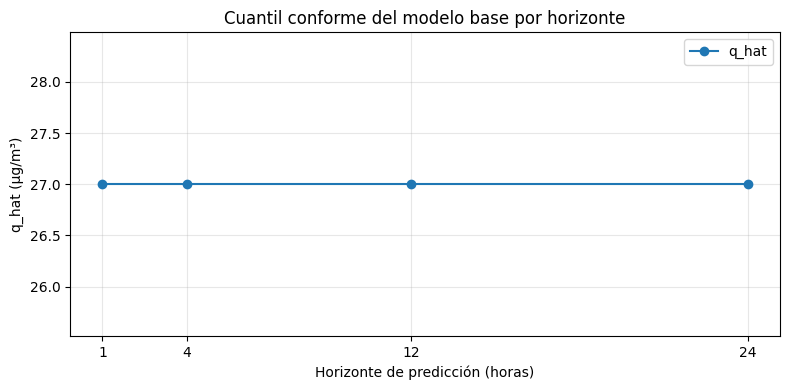

In [22]:

fig, ax = plt.subplots(figsize=(8, 4))

plot_df = calibration_summary_df.sort_values("horizon")
ax.plot(plot_df["horizon"], plot_df["q_hat"], marker="o", label="q_hat")

ax.set_title("Cuantil conforme del modelo base por horizonte")
ax.set_xlabel("Horizonte de predicción (horas)")
ax.set_ylabel("q_hat (µg/m³)")
ax.set_xticks(HORIZONS)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

qhat_figure_path = REPORTS_FIGURES_DIR / "fig_split_conformal_baseline_qhat.png"
fig.savefig(qhat_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {qhat_figure_path}")
plt.show()



## Figura 2 - Métricas de intervalos en validación

Esta figura resume el comportamiento de los intervalos del modelo base: cobertura, anchura media e *interval score*.


Figura guardada en: c:\trabajo_github\reports\figures\fig_split_conformal_baseline_interval_metrics.png


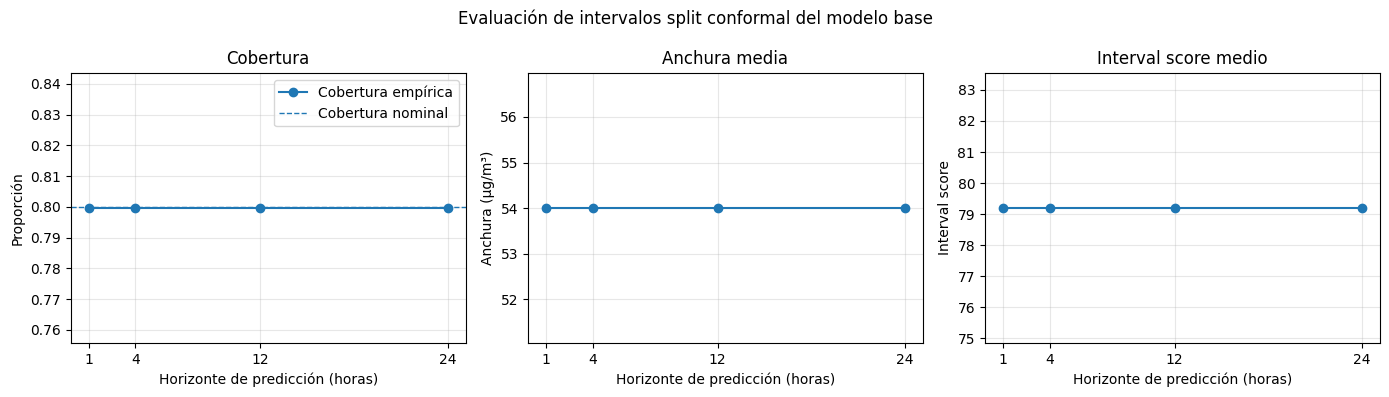

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
plot_df = interval_metrics_df.sort_values("horizon")

axes[0].plot(plot_df["horizon"], plot_df["empirical_coverage"], marker="o", label="Cobertura empírica")
axes[0].axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1, label="Cobertura nominal")
axes[0].set_title("Cobertura")
axes[0].set_ylabel("Proporción")
axes[0].legend(loc="best")

axes[1].plot(plot_df["horizon"], plot_df["mean_width"], marker="o")
axes[1].set_title("Anchura media")
axes[1].set_ylabel("Anchura (µg/m³)")

axes[2].plot(plot_df["horizon"], plot_df["mean_interval_score"], marker="o")
axes[2].set_title("Interval score medio")
axes[2].set_ylabel("Interval score")

for ax in axes:
    ax.set_xlabel("Horizonte de predicción (horas)")
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

fig.suptitle("Evaluación de intervalos split conformal del modelo base")
fig.tight_layout()

metrics_figure_path = REPORTS_FIGURES_DIR / "fig_split_conformal_baseline_interval_metrics.png"
fig.savefig(metrics_figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {metrics_figure_path}")
plt.show()



## Figura 3 - Inspección visual de intervalos

Se selecciona automáticamente un tramo continuo de validación para representar el valor observado, la predicción puntual y el intervalo construido mediante *split conformal*. La figura es meramente ilustrativa; las métricas se calculan sobre todas las observaciones evaluables del conjunto de validación.


In [24]:


def select_continuous_block(intervals: pd.DataFrame, n_hours: int) -> pd.DataFrame:
    """Selecciona el primer bloque continuo de `n_hours` si existe."""
    df = intervals.sort_values("target_timestamp").copy()
    df["delta_h"] = df["target_timestamp"].diff() / pd.Timedelta(hours=1)
    df["continuous_block"] = (df["delta_h"].isna() | (df["delta_h"] != 1)).cumsum()

    block_summary = (
        df.groupby("continuous_block")
        .agg(
            start=("target_timestamp", "min"),
            end=("target_timestamp", "max"),
            n_hours=("target_timestamp", "count"),
        )
        .reset_index()
    )

    candidate_blocks = block_summary.loc[block_summary["n_hours"] >= n_hours]

    if candidate_blocks.empty:
        selected_block_id = (
            block_summary.sort_values(["n_hours", "start"], ascending=[False, True])
            .iloc[0]["continuous_block"]
        )
        print(
            f"No se encontró un bloque continuo de {n_hours} horas. "
            "Se utilizará el bloque continuo más largo disponible."
        )
    else:
        selected_block_id = candidate_blocks.sort_values("start").iloc[0]["continuous_block"]

    selected = df.loc[df["continuous_block"] == selected_block_id].copy()
    selected = selected.head(n_hours).reset_index(drop=True)

    # Se eliminan columnas auxiliares antes de guardar o mostrar el tramo.
    return selected.drop(columns=["delta_h", "continuous_block"], errors="ignore")


example_intervals = baseline_intervals.loc[baseline_intervals["horizon"] == EXAMPLE_HORIZON].copy()
example_block = select_continuous_block(example_intervals, n_hours=EXAMPLE_HOURS)

example_block_path = REPORTS_TABLES_DIR / f"split_conformal_baseline_example_block_h{EXAMPLE_HORIZON:02d}.csv"
example_block.to_csv(example_block_path, index=False)

print(
    "Tramo seleccionado:",
    example_block["target_timestamp"].min(),
    "→",
    example_block["target_timestamp"].max(),
    f"({len(example_block)} horas)",
)
print(f"Tabla del tramo guardada en: {example_block_path}")


Tramo seleccionado: 2024-03-01 11:00:00 → 2024-03-15 10:00:00 (336 horas)
Tabla del tramo guardada en: c:\trabajo_github\reports\tables\split_conformal_baseline_example_block_h24.csv


Figura guardada en: c:\trabajo_github\reports\figures\fig_split_conformal_baseline_interval_zoom_h24.png


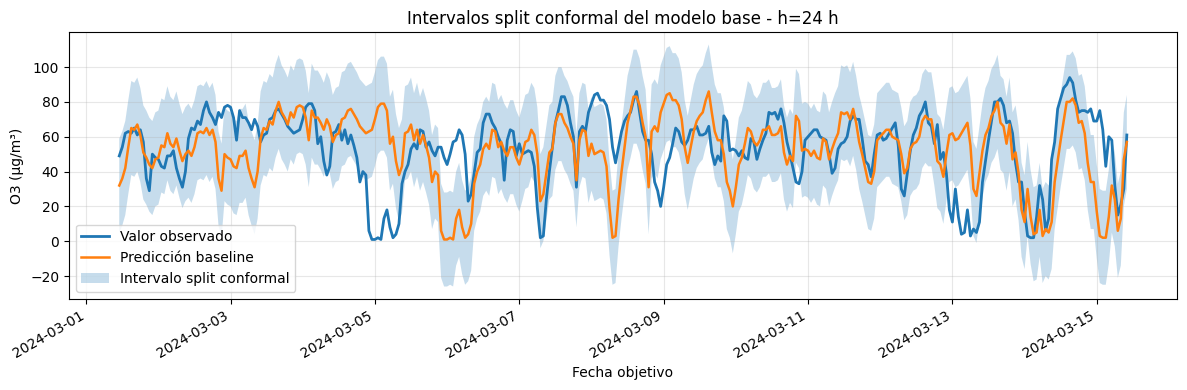

In [25]:

fig, ax = plt.subplots(figsize=(12, 4))

x_values = example_block["target_timestamp"]

ax.plot(x_values, example_block["y_true"], label="Valor observado", linewidth=2)
ax.plot(x_values, example_block["y_pred"], label="Predicción baseline", linewidth=1.8)
ax.fill_between(
    x_values,
    example_block["lower"],
    example_block["upper"],
    alpha=0.25,
    label="Intervalo split conformal",
)

ax.set_title(f"Intervalos split conformal del modelo base - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel("O3 (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()

interval_zoom_path = REPORTS_FIGURES_DIR / f"fig_split_conformal_baseline_interval_zoom_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(interval_zoom_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {interval_zoom_path}")
plt.show()



## Comprobaciones finales

Estas comprobaciones verificarán que la calibración y la evaluación se han realizado sin utilizar el conjunto de prueba.


In [26]:

assert not calibration_summary_df.empty, "La tabla de calibración está vacía."
assert not interval_metrics_df.empty, "La tabla de métricas de intervalos está vacía."
assert not baseline_intervals.empty, "No se han generado intervalos."
assert TEST_SPLIT not in baseline_intervals["split"].unique(), "Se han generado intervalos sobre el conjunto de prueba."
assert np.isfinite(calibration_summary_df["q_hat"]).all(), "Algún cuantil conforme no es finito."

expected_interval_files = [
    REPORTS_INTERVALS_DIR / f"{INTERVAL_PREFIX}_h{h:02d}.parquet" for h in HORIZONS
]
missing_interval_files = [path for path in expected_interval_files if not path.exists()]
assert not missing_interval_files, f"Faltan archivos de intervalos: {missing_interval_files}"

print("Comprobaciones finales superadas correctamente.")
print("- No se ha utilizado el conjunto de prueba.")
print("- Se han calibrado cuantiles conformes para todos los horizontes.")
print("- Se han generado intervalos y métricas en validación.")
print("- Archivos de intervalos guardados correctamente.")


Comprobaciones finales superadas correctamente.
- No se ha utilizado el conjunto de prueba.
- Se han calibrado cuantiles conformes para todos los horizontes.
- Se han generado intervalos y métricas en validación.
- Archivos de intervalos guardados correctamente.



## Salidas generadas

Este notebook genera los siguientes artefactos principales:

**Intervalos:**

- `reports/intervals/split_conformal_baseline_h01.parquet`
- `reports/intervals/split_conformal_baseline_h04.parquet`
- `reports/intervals/split_conformal_baseline_h12.parquet`
- `reports/intervals/split_conformal_baseline_h24.parquet`

**Tablas:**

- `reports/tables/split_conformal_baseline_calibration_summary.csv`
- `reports/tables/split_conformal_baseline_calibration_residuals.csv`
- `reports/tables/split_conformal_baseline_interval_metrics.csv`
- `reports/tables/split_conformal_baseline_prediction_availability.csv`

**Figuras:**

- `reports/figures/fig_split_conformal_baseline_qhat.png`
- `reports/figures/fig_split_conformal_baseline_interval_metrics.png`
- `reports/figures/fig_split_conformal_baseline_interval_zoom_h24.png`
